In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [50]:
data = pd.read_csv('Student_performance_10k.csv')
print('Shape:', data.shape)
data.head()

Shape: (10000, 12)


,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [51]:
print(data.isnull().sum())
print('\nTotal missing:', data.isnull().sum().sum())
print("Duplicates:", data.duplicated().sum())

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     24
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64

Total missing: 229
Duplicates: 0


In [52]:
score_cols = ['math_score', 'reading_score', 'writing_score', 'science_score', 'total_score']
for col in score_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [53]:
data.dropna(inplace=True)

In [54]:
data.drop(columns=['roll_no'], inplace=True)

In [55]:
print('\nAfter Cleaning:')
print('Shape:', data.shape)
print('Missing values:', data.isnull().sum().sum())


After Cleaning:
Shape: (9786, 11)
Missing values: 0


In [56]:
counts = data['grade'].value_counts().sort_index()
print(counts)

grade
A        895
B       5543
C       2628
D        659
Fail      61
Name: count, dtype: int64


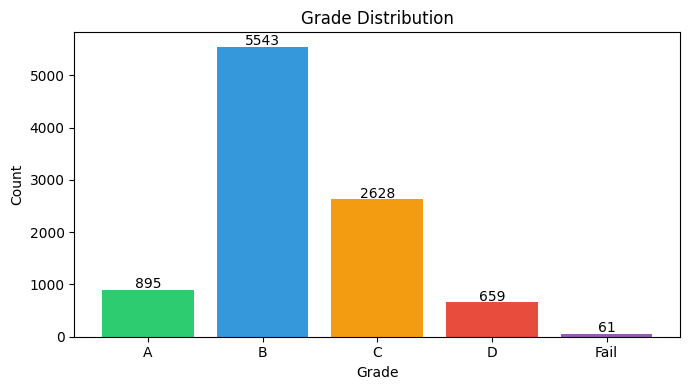

In [57]:
plt.figure(figsize=(7,4))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']
bars = plt.bar(counts.index,counts.values,color=colors[:len(counts)])
for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 30,str(value),ha='center')
    plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [58]:
score_features = [
    'math_score',
    'reading_score',
    'writing_score',
    'science_score'
]

print("Shape before outlier removal:", data.shape)

Shape before outlier removal: (9786, 11)


In [59]:
for col in score_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

In [60]:
print("Shape after outlier removal:", data.shape)

Shape after outlier removal: (9786, 11)


In [61]:
le_gender = LabelEncoder()
le_race = LabelEncoder()
le_edu = LabelEncoder()

data['gender'] = le_gender.fit_transform(data['gender'])
data['race_ethnicity'] = le_race.fit_transform(data['race_ethnicity'])
data['parental_level_of_education'] = le_edu.fit_transform(data['parental_level_of_education'])

In [62]:
le = LabelEncoder()
data['grade'] = le.fit_transform(data['grade'])

print("Target classes:", le.classes_)

Target classes: ['A' 'B' 'C' 'D' 'Fail']


In [63]:
X = data.drop(columns=['grade', 'total_score'])
y = data['grade']

In [64]:
print("Selected features:", X.columns.tolist())
print("X shape:", X.shape, "| y shape:", y.shape)

Selected features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score']
X shape: (9786, 9) | y shape: (9786,)


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)
print('Train set:', X_train.shape)
print('Test  set:', X_test.shape)

Train set: (7828, 9)
Test  set: (1958, 9)


In [66]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [67]:
dt = DecisionTreeClassifier(random_state=23)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

In [68]:
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted')
dt_rec = recall_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree")
print("Accuracy :", dt_acc)
print("Precision:", dt_prec)
print("Recall   :", dt_rec)

Decision Tree
Accuracy : 0.8707865168539326
Precision: 0.871460832628231
Recall   : 0.8707865168539326


In [69]:
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

              precision    recall  f1-score   support

           A       0.85      0.77      0.81       179
           B       0.92      0.91      0.92      1109
           C       0.82      0.85      0.83       526
           D       0.77      0.73      0.75       132
        Fail       0.62      0.83      0.71        12

    accuracy                           0.87      1958
   macro avg       0.79      0.82      0.80      1958
weighted avg       0.87      0.87      0.87      1958



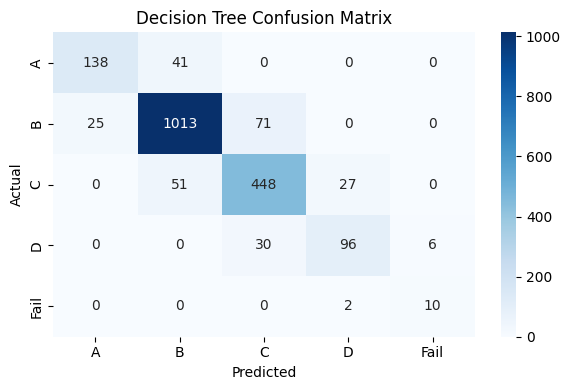

In [70]:
# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [71]:
rf = RandomForestClassifier(n_estimators=100, random_state=23)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [72]:
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec = recall_score(y_test, y_pred_rf, average='weighted')

print("Random Forest")
print("Accuracy :", rf_acc)
print("Precision:", rf_prec)
print("Recall   :", rf_rec)

Random Forest
Accuracy : 0.9218590398365679
Precision: 0.9231051768007831
Recall   : 0.9218590398365679


In [73]:
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

              precision    recall  f1-score   support

           A       0.99      0.76      0.86       179
           B       0.93      0.98      0.95      1109
           C       0.90      0.91      0.91       526
           D       0.90      0.72      0.80       132
        Fail       1.00      0.33      0.50        12

    accuracy                           0.92      1958
   macro avg       0.94      0.74      0.80      1958
weighted avg       0.92      0.92      0.92      1958



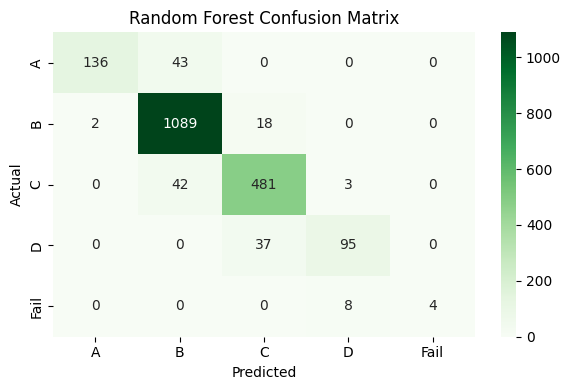

In [74]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [75]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [76]:
knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec = recall_score(y_test, y_pred_knn, average='weighted')

print("KNN (K=5)")
print("Accuracy :", knn_acc)
print("Precision:", knn_prec)
print("Recall   :", knn_rec)

KNN (K=5)
Accuracy : 0.8289070480081716
Precision: 0.8276650528649251
Recall   : 0.8289070480081716


In [77]:
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

              precision    recall  f1-score   support

           A       0.83      0.55      0.66       179
           B       0.85      0.94      0.89      1109
           C       0.79      0.79      0.79       526
           D       0.79      0.47      0.59       132
        Fail       1.00      0.17      0.29        12

    accuracy                           0.83      1958
   macro avg       0.85      0.58      0.64      1958
weighted avg       0.83      0.83      0.82      1958



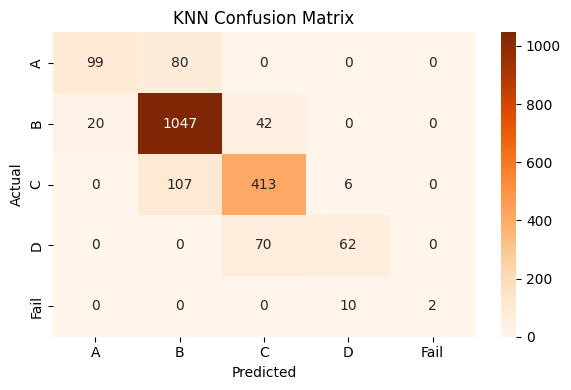

In [78]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [79]:
results_df = pd.DataFrame({
    'Algorithm': ['Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy' : [dt_acc, rf_acc, knn_acc],
    'Precision': [dt_prec, rf_prec, knn_prec],
    'Recall'   : [dt_rec, rf_rec, knn_rec]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results_df)

       Algorithm  Accuracy  Precision    Recall
0  Random Forest  0.921859   0.923105  0.921859
1  Decision Tree  0.870787   0.871461  0.870787
2            KNN  0.828907   0.827665  0.828907


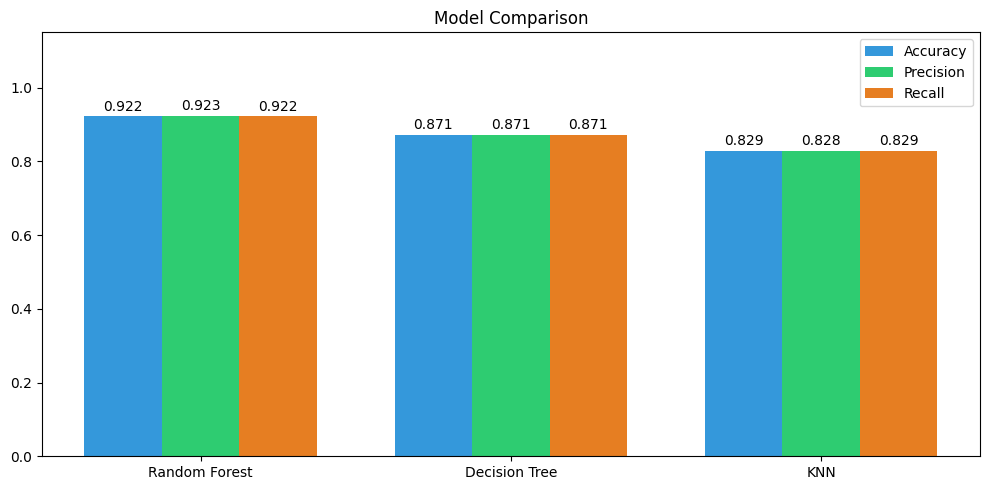

In [80]:
x = np.arange(len(results_df))
w = 0.25

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x - w, results_df['Accuracy'],  w, label='Accuracy',  color='#3498db')
ax.bar(x,     results_df['Precision'], w, label='Precision', color='#2ecc71')
ax.bar(x + w, results_df['Recall'],    w, label='Recall',    color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Algorithm'])

ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison')

ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2)

plt.tight_layout()
plt.show()

In [81]:
best = results_df.iloc[0]

print("Best Model:", best['Algorithm'])
print("Accuracy  :", best['Accuracy'])
print("Precision :", best['Precision'])
print("Recall    :", best['Recall'])

Best Model: Random Forest
Accuracy  : 0.9218590398365679
Precision : 0.9231051768007831
Recall    : 0.9218590398365679
